# Latent-bridge v2 and Anthropic lens benchmarks — GPT-2 XL

**Question.** Does a fitted Jacobian lens reveal annotated intermediates better than the logit lens, and at which prompt positions and depths?

**Answer in the committed run.** The offline integration run completes both benchmark paths, with identical results for an identity J-lens and the logit lens. It uses a random tiny Llama, so its tables and plots are **pipeline checks, not evidence about trained-model quality**. Select `RUN_MODE = "pretrained"` and supply a matching fitted lens below to obtain an empirical answer; the final cell derives conclusions from that run.

This notebook replaces the earlier GPT-2 XL position benchmark at this path (see the git history), adapted to any `LensModel`. It includes all 530 latent-bridge candidates and all six local Anthropic evaluation sets, plus the locally authored [multihop-easy dataset](../../../data/evaluations/lens-eval-multihop-easy.json) (200 prompts, 100 base items). Smoke mode takes two examples per original family/dataset and both phrasings of one base item per multihop-easy family. The source notebook's GPT-2-selected 354 subjects remain a historical subset; they are not assumed to be correct for another model.

The experiment uses `jlens.from_hf`, explicit prompt encoding, strict whole-token scoring, and shared batched activations. It needs an existing compatible lens; fit one on independent text using [the model-agnostic fitting notebook](../../model_agnostic/model_agnostic_lens_dataset.ipynb). The GPT-2-specific swap/probe checkpoints are not inputs to this comparison.

## Method and interpretation

* **Latent bridge:** keep `[block, token position]` ranks for the country, a different same-family control country, and the target language. Min-reduce over subject, country token(s), other template, last, slot, all-but-slot, or all positions. Character offsets define spans even when words split into multiple tokens. The slot is the final token of `in`/`from` before `a country`, where the country would be a literal next-word prediction. Inner layers exclude the final block.
* **Anthropic datasets:** use the readout positions in [the local protocol](../../../data/evaluations/README.md): multihop, multilingual, order-ops, association and typo use the final prompt token; poetry uses the last newline token. Do not sweep positions for their protocol scores. Report the protocol's all-layer result as well as inner-layer and final-output diagnostics.
* **Multihop-easy:** use the final prompt token, with no order-ops synonym expansion. Average word hits within a prompt, phrasings within `base_id`, base items within each family, then families equally. Retain `group_id` and dev/test labels; report all/dev/test separately. These are unfiltered candidates, not established small-model successes. Hop diagnostic prompts are metadata only and are never appended to evaluation context.
* **Scoring:** rank the best exact decoded whole-token spelling, accepting case and leading-space variants; order-ops also expands number/operation synonyms. No prefix fallback. Unsupported annotations retain null ranks and are excluded, with word and item coverage shown. Scores average word hits within each item, then weight eligible items equally. Controls are descriptive baselines, not calibrated chance probabilities.
* **Readout:** final norm, LM head and optional softcap belong to the adapter. Lexical ranks use pre-softcap scores and ascending token ID to break ties; model correctness uses the actual distribution argmax. Both lenses share the untransported final block.
* **Encoding:** preserve source whitespace, use the configured BOS policy, apply no chat template, and reject overlength prompts. Thus trailing spaces may form the final token. These strict semantics can differ from older notebooks that stripped prompts or accepted answer prefixes; these results are an adaptation, not an exact reproduction of Anthropic's model or published numbers.
* **Compute:** sort by length and right-pad with masks when supported, otherwise group equal lengths. Each batch shares one model pass across lenses. Chunk vocabulary readouts; retain only ranks between batches. Full batch activations and one fp32 Jacobian per inner block still consume memory.

In [1]:
import hashlib
import json
import os
import sys
from pathlib import Path

REPO = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "jlens" / "position_benchmark.py").is_file()), None,
)
if REPO is None:
    raise RuntimeError("Open this notebook from a repository checkout; run uv sync --extra dev first.")
sys.path.insert(0, str(REPO))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformers
from IPython.display import Markdown, display
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer

import jlens
from jlens.batched_evaluation import evaluate_paired_batched
from jlens.evaluation import DATASETS, identity_lens, load_eval, pass_at_k
from jlens.position_benchmark import (
    evaluate_position_ranks,
    latent_bridge_spans,
    load_latent_bridge,
    reduce_position_ranks,
)
from jlens.strict_scoring import DecodedSpellings, ExplicitPromptModel

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)

## Configuration

For a trained run, set `RUN_MODE`, `MODEL_ID`, `MODEL_REVISION`, `LENS_PATH`, and the fit provenance. Use the BOS policy used when fitting the lens (`prepend` needs a BOS ID; `none` or `tokenizer` are available). Choose a dtype your device supports. The model loader uses one CPU or CUDA device; other compatible `LensModel` adapters can be supplied by replacing the loading cell.

A checkpoint's dimensions cannot establish which model or corpus produced it. Record unknown provenance explicitly rather than inferring it. Nothing here refits a lens on evaluation prompts. Smoke mode uses a synthetic tokenizer and identity matrices solely to test notebook execution, without downloading weights.

In [3]:
RUN_MODE = "pretrained"  # "smoke" runs the offline pipeline check
MODEL_ID = "openai-community/gpt2-xl"
MODEL_REVISION = "main"  # Pin a Hub commit for a reproducible trained run.
LENS_PATH = Path(os.environ.get(
    "JLENS_LENS_PATH", REPO / "runs/gpt2-xl-convergence/snapshot_lens_134.pt",
)).expanduser()
FIT_PROVENANCE = {  # snapshot_lens_134.pt: notebooks/gpt2-xl/jacobian_lens/jacobian_logit_lens_dataset.ipynb
    "model_id": MODEL_ID,
    "model_revision": None,  # not recorded at fit time
    "dtype": "float32",
    "corpus_mix": "jlens.evaluation.FIT_MIX x 0.25 = 134 prompts",
    "sequence_length": 128,
    "dimension_batch_size": None,  # selected automatically at fit time, not recorded
}
BOS_POLICY = "prepend"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32
BATCH_SIZE = 32
MAX_BATCH_TOKENS = 4096
MAX_SEQ_LEN = 512
POSITION_CHUNK_SIZE = 8
RANK_CHUNK_SIZE = 8
K_VALUES = [1, 2, 5, 10, 20, 50, 100]
K = 10
SMOKE_ITEMS_PER_DATASET = 2
CACHE_ROOT = REPO / "runs/model-agnostic-lens-benchmark"
FORCE_RECOMPUTE = False
COLORS = {"logit lens": "#eb6834", "J-lens": "#2a78d6"}

if RUN_MODE not in {"smoke", "pretrained"}:
    raise ValueError("RUN_MODE must be smoke or pretrained")

In [4]:
latent_evals = load_latent_bridge(REPO)
anthropic_evals = {dataset: load_eval(str(REPO), dataset) for dataset in [*DATASETS, "multihop-easy"]}
full_counts = {name: len(items) for name, items in {**latent_evals, **anthropic_evals}.items()}
if RUN_MODE == "smoke":
    latent_evals = {name: items[:SMOKE_ITEMS_PER_DATASET] for name, items in latent_evals.items()}
    easy_frame = pd.DataFrame(anthropic_evals["multihop-easy"])
    smoke_bases = easy_frame.drop_duplicates("family").base_id
    anthropic_evals = {
        name: ([item for item in items if item["base_id"] in set(smoke_bases)]
               if name == "multihop-easy" else items[:SMOKE_ITEMS_PER_DATASET])
        for name, items in anthropic_evals.items()
    }
easy_metadata = pd.DataFrame(anthropic_evals["multihop-easy"])[
    ["name", "base_id", "family", "group_id", "split", "template_id"]
].rename(columns={"name": "item"})
assert easy_metadata.groupby("base_id").size().eq(2).all()
selected_evals = {**latent_evals, **anthropic_evals}
display(pd.DataFrame([
    {"dataset": name, "available": full_counts[name], "selected": len(items),
     "annotated_intermediates": sum(len(item["intermediates"]) for item in items),
     "annotated_targets": sum("target" in item for item in items)}
    for name, items in selected_evals.items()
]).set_index("dataset"))

,available,selected,annotated_intermediates,annotated_targets
dataset,,,,
latent-bridge/landmark,108,108,108,108
latent-bridge/city,119,119,119,119
latent-bridge/person,117,117,117,117
latent-bridge/brand,83,83,83,83
latent-bridge/food,103,103,103,103
multihop,93,93,103,93
multilingual,107,107,428,107
order-ops,55,55,110,55
poetry,98,98,98,0


## Model identity and cache provenance

The cache key covers the selected prompts, model/config revision, full tokenizer serialization, BOS/dtype/device, lens SHA-256, fit metadata, chunk settings, relevant implementation files, package versions and notebook code. Editing an input or scoring implementation creates a separate run directory. A cache hit skips weight loading and all forwards; plots and summaries are rebuilt from the saved ranks. Cached `.pkl`, `.pt` and generated figures live in ignored `runs/`.

In [5]:
def digest_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def digest_json(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, default=str).encode()).hexdigest()


if RUN_MODE == "smoke":
    from tokenizers import Regex, Tokenizer, models, pre_tokenizers
    from transformers import LlamaConfig, PreTrainedTokenizerFast

    # Preserve newlines as tokens so poetry's readout is exercised offline.
    splitter = pre_tokenizers.Sequence([
        pre_tokenizers.Split(Regex(r"\n"), behavior="isolated"),
        pre_tokenizers.Split(Regex(r"[^\S\n]+"), behavior="removed"),
    ])
    texts = [item["prompt"] for items in selected_evals.values() for item in items]
    labels = [word for items in selected_evals.values() for item in items
              for word in [*item["intermediates"], *item.get("controls", []), item.get("target", "")]]
    pieces = {piece for text in texts + labels for piece, _ in splitter.pre_tokenize_str(text)}
    vocab = {token: i for i, token in enumerate(["[UNK]", "[BOS]", "[PAD]", *sorted(pieces)])}
    backend = Tokenizer(models.WordLevel(vocab, unk_token="[UNK]"))
    backend.pre_tokenizer = splitter
    tokenizer = PreTrainedTokenizerFast(
        tokenizer_object=backend, unk_token="[UNK]", bos_token="[BOS]", pad_token="[PAD]",
    )
    config = LlamaConfig(
        vocab_size=len(tokenizer), hidden_size=16, intermediate_size=32,
        num_hidden_layers=3, num_attention_heads=2, num_key_value_heads=1,
        max_position_embeddings=MAX_SEQ_LEN, bos_token_id=tokenizer.bos_token_id,
        pad_token_id=tokenizer.pad_token_id, eos_token_id=None,
    )
    run_model_id, resolved_revision = "offline/random-tiny-llama", "seed-0"
    lens_identity = "identity-matrices-v1"
    fit_metadata = {"method": "identity; no fitting", "corpus_mix": None,
                    "sequence_length": None, "dimension_batch_size": None}
    run_device, run_dtype = "cpu", torch.float32
else:
    if not LENS_PATH.is_file():
        raise FileNotFoundError(f"Set LENS_PATH to a fitted lens for {MODEL_ID}: {LENS_PATH}")
    if FIT_PROVENANCE["model_id"] != MODEL_ID:
        raise ValueError("Lens provenance model_id differs from MODEL_ID")
    config = AutoConfig.from_pretrained(MODEL_ID, revision=MODEL_REVISION)
    resolved_revision = getattr(config, "_commit_hash", None)
    if resolved_revision is None:
        # Newer transformers no longer record the commit on the config; the snapshot directory is named by it.
        from huggingface_hub import snapshot_download
        resolved_revision = Path(snapshot_download(
            MODEL_ID, revision=MODEL_REVISION, allow_patterns=["config.json"],
        )).name
    if resolved_revision is None:
        raise ValueError("Use a Hub model ID with an immutable resolved revision for cache identity")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, revision=resolved_revision, use_fast=True)
    if FIT_PROVENANCE["model_revision"] not in {None, resolved_revision}:
        raise ValueError("Lens provenance revision differs from the selected model")
    run_model_id, lens_identity = MODEL_ID, digest_file(LENS_PATH)
    fit_metadata = FIT_PROVENANCE.copy()
    run_device, run_dtype = DEVICE, DTYPE
if not tokenizer.is_fast:
    raise ValueError("This benchmark requires fast-tokenizer offsets for latent spans")

implementation = [
    "jlens/position_benchmark.py", "jlens/batched_evaluation.py", "jlens/evaluation.py",
    "jlens/hf.py", "jlens/readout.py", "jlens/strict_scoring.py", "jlens/lens.py", "jlens/hooks.py",
]
notebook_path = REPO / "notebooks/gpt2-xl/latent_bridge_v2/latent_bridge_v2_lens_benchmark.ipynb"
notebook_code = ["".join(cell["source"]) for cell in json.loads(notebook_path.read_text())["cells"]
                 if cell["cell_type"] == "code"]
manifest = {
    "schema": 1, "mode": RUN_MODE, "model": run_model_id, "revision": resolved_revision,
    "config": config.to_dict(), "tokenizer": tokenizer.backend_tokenizer.to_str(),
    "special_tokens": tokenizer.special_tokens_map, "bos_policy": BOS_POLICY,
    "dtype": str(run_dtype), "device": run_device, "lens_sha256_or_identity": lens_identity,
    "fit": fit_metadata, "evals_sha256": digest_json(selected_evals),
    "implementation": {name: digest_file(REPO / name) for name in implementation},
    "notebook_code_sha256": digest_json(notebook_code),
    "versions": {"torch": torch.__version__, "transformers": transformers.__version__,
                 "numpy": np.__version__, "pandas": pd.__version__},
    "matmul_precision": torch.get_float32_matmul_precision(),
    "batch_size": BATCH_SIZE, "max_batch_tokens": MAX_BATCH_TOKENS,
    "max_seq_len": MAX_SEQ_LEN, "position_chunk_size": POSITION_CHUNK_SIZE,
    "rank_chunk_size": RANK_CHUNK_SIZE,
    "scoring": "decoded-whole-token; lexical pre-softcap; ties by token ID; whitespace preserved",
}
RUN_DIR = CACHE_ROOT / digest_json(manifest)[:20]
RUN_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH = RUN_DIR / "results.pkl"
(RUN_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, default=str) + "\n")
print(f"Mode: {RUN_MODE}; model: {run_model_id}; revision: {resolved_revision}")
print(f"Cache: {CACHE_PATH.relative_to(REPO)}")
print("Fitting provenance:", fit_metadata)

Mode: pretrained; model: openai-community/gpt2-xl; revision: 15ea56dee5df4983c59b2538573817e1667135e2
Cache: runs/model-agnostic-lens-benchmark/fe081dc72c96ff8ca50c/results.pkl
Fitting provenance: {'model_id': 'openai-community/gpt2-xl', 'model_revision': None, 'dtype': 'float32', 'corpus_mix': 'jlens.evaluation.FIT_MIX x 0.25 = 134 prompts', 'sequence_length': 128, 'dimension_batch_size': None}


## Run or restore

A fresh run uses the same strict spelling lookup and lens for both suites. Latent controls are chosen before smoke subsampling. Anthropic controls use the evaluator's deterministic shifted item within each selected dataset; controls identical to an item's intermediate are omitted. Null target correctness means unsupported or unannotated, not wrong.

Multihop-easy uses the same shifted-item control policy; these controls are not family matched. Smoke subsampling can omit controls identical to the intermediate. The full dataset order guarantees distinct shifted controls.

In [6]:
# Clear old in-memory results before a failed or interrupted rerun can reuse them.
position_words = latent_items = anth_words = anth_items = span_words = None
if CACHE_PATH.exists() and not FORCE_RECOMPUTE:
    payload = pd.read_pickle(CACHE_PATH)
    if payload["manifest"] != manifest:
        raise ValueError("Cache manifest mismatch; remove this cache and rerun")
    print("Restored cached ranks; no model weights loaded or forwards run.")
else:
    if RUN_MODE == "smoke":
        torch.manual_seed(0)
        hf_model = AutoModelForCausalLM.from_config(config).to(run_device).eval()
    else:
        hf_model = AutoModelForCausalLM.from_pretrained(
            MODEL_ID, revision=resolved_revision, dtype=run_dtype,
        ).to(run_device).eval()
    model = ExplicitPromptModel(
        jlens.from_hf(hf_model, tokenizer, compile=False, force_bos=False),
        bos_policy=BOS_POLICY,
    )
    fitted_lens = identity_lens(model) if RUN_MODE == "smoke" else jlens.JacobianLens.load(str(LENS_PATH))
    if model.n_layers < 2 or fitted_lens.d_model != model.d_model:
        raise ValueError("Need at least two model blocks and a matching lens width")
    spans = {
        (dataset, item["name"]): latent_bridge_spans(model, item, max_seq_len=MAX_SEQ_LEN)
        for dataset, samples in latent_evals.items() for item in samples
    }
    spellings = DecodedSpellings(tokenizer, vocab_size=hf_model.get_output_embeddings().weight.shape[0])
    options = dict(
        spelling_lookup=spellings, batch_size=BATCH_SIZE, max_batch_tokens=MAX_BATCH_TOKENS,
        max_seq_len=MAX_SEQ_LEN, position_chunk_size=POSITION_CHUNK_SIZE,
        rank_chunk_size=RANK_CHUNK_SIZE, progress=True,
    )
    position_words, latent_items = evaluate_position_ranks(model, fitted_lens, latent_evals, **options)
    anth_words, anth_items = evaluate_paired_batched(model, fitted_lens, anthropic_evals, **options)
    payload = {"manifest": manifest, "position_words": position_words, "latent_items": latent_items,
               "anth_words": anth_words, "anth_items": anth_items, "spans": spans, "n_layers": model.n_layers}
    temporary = CACHE_PATH.with_suffix(".tmp")
    pd.to_pickle(payload, temporary)
    temporary.replace(CACHE_PATH)
    del model, hf_model, fitted_lens, spellings
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

position_words, latent_items, anth_words, anth_items = (
    payload[name] for name in ["position_words", "latent_items", "anth_words", "anth_items"]
)
N_LAYERS = payload["n_layers"]
INNER = slice(None, -1)
span_words = reduce_position_ranks(position_words, payload["spans"])
print(f"{N_LAYERS} block outputs; inner blocks 0–{N_LAYERS - 2}; final block {N_LAYERS - 1}.")
display(pd.DataFrame({
    "latent bridge": position_words.attrs["evaluation"],
    "single-position datasets": anth_words.attrs["evaluation"],
}).T)

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

all-position ranks:   0%|          | 0/17 [00:00<?, ?it/s]

batched paired lenses:   0%|          | 0/24 [00:00<?, ?batch/s]

48 block outputs; inner blocks 0–46; final block 47.


,n_model_passes,batch_sizes,batching,bos_policy,n_items,batch_size,max_batch_tokens,max_seq_len,position_chunk_size,rank_chunk_size
latent bridge,17,"[32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 3...",padded,prepend,NaN,NaN,NaN,NaN,NaN,NaN
single-position datasets,24,"[32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 3...",padded,prepend,751,32,4096,512,8,8


In [7]:
# Paired final-output identity is a required invariant for any fitted lens.
for frame in (position_words, anth_words):
    keys = ["dataset", "item", "kind", "word", "role"]
    left = frame[frame.lens.eq("logit lens")].set_index(keys)
    right = frame[frame.lens.eq("J-lens")].set_index(keys).reindex(left.index)
    assert left.ranks.isna().equals(right.ranks.isna())
    for a, b in zip(left.ranks, right.ranks, strict=True):
        if a is not None:
            np.testing.assert_array_equal(a[-1], b[-1])
            if RUN_MODE == "smoke":
                np.testing.assert_array_equal(a, b)
print("Shared final-output ranks verified; identity ranks also verified in smoke mode.")

anth_model_items = anth_items[anth_items.lens.eq("logit lens")].copy()
model_items = pd.concat([latent_items, anth_model_items], ignore_index=True)
accuracy = model_items.assign(
    annotated=model_items.target.notna(), supported=model_items.model_correct.notna(),
    correct=model_items.model_correct.eq(True),
).groupby("dataset").agg(
    items=("item", "size"), annotated=("annotated", "sum"),
    supported=("supported", "sum"), correct=("correct", "sum"),
)
accuracy["unsupported"] = accuracy.annotated - accuracy.supported
accuracy["unannotated"] = accuracy["items"] - accuracy.annotated
accuracy["top1_accuracy"] = accuracy.correct / accuracy.supported.replace(0, np.nan)
display(accuracy)

Shared final-output ranks verified; identity ranks also verified in smoke mode.


,items,annotated,supported,correct,unsupported,unannotated,top1_accuracy
dataset,,,,,,,
association,102,0,0,0,0,102,NaN
latent-bridge/brand,83,83,83,53,0,0,0.638554
latent-bridge/city,119,119,119,99,0,0,0.831933
latent-bridge/food,103,103,103,61,0,0,0.592233
latent-bridge/landmark,108,108,108,74,0,0,0.685185
latent-bridge/person,117,117,117,89,0,0,0.760684
multihop,93,93,92,2,1,0,0.021739
multihop-easy,200,200,196,29,4,0,0.147959
multilingual,107,107,19,0,88,0,0.000000


## Coverage and subsets

Whole-token coverage is tokenizer-dependent. Compare models alongside their coverage, rather than counting an unrepresentable word as a failed readout. Target accuracy is a lexical next-token diagnostic, not generated multi-token answer accuracy. The `current model correct` subset conditions on the two-hop language answer only; it does not rerun the source experiment's direct-hop filters.

In [8]:
coverage_source = pd.concat([
    position_words.assign(suite="latent bridge"), anth_words.assign(suite="single-position datasets"),
], ignore_index=True)
coverage = coverage_source.assign(supported=coverage_source.ranks.notna()).groupby(
    ["suite", "dataset", "lens", "kind"]
).supported.agg(["sum", "size", "mean"]).rename(
    columns={"sum": "scored_words", "size": "total_words", "mean": "coverage"},
)
display(coverage.xs("logit lens", level="lens"))
print("Coverage is identical across lenses (checked above).")

latent_metadata = latent_items[["dataset", "item", "gpt2_kept", "model_correct"]]
span_words = span_words.merge(latent_metadata, on=["dataset", "item"], validate="many_to_one")
latent_subsets = {
    "all candidates": span_words,
    "current model correct": span_words[span_words.model_correct.eq(True)],
    "historical GPT-2 kept": span_words[span_words.gpt2_kept],
}
display(pd.DataFrame([
    {"subset": name, "items": frame[["dataset", "item"]].drop_duplicates().shape[0]}
    for name, frame in latent_subsets.items()
]))

scored_words  total_words  coverage
suite                    dataset                kind                                             
latent bridge            latent-bridge/brand    control                 83           83  1.000000
                                                intermediate            83           83  1.000000
                                                target                  83           83  1.000000
                         latent-bridge/city     control                119          119  1.000000
                                                intermediate           119          119  1.000000
                                                target                 119          119  1.000000
                         latent-bridge/food     control                103          103  1.000000
                                                intermediate           103          103  1.000000
                                                target                 103          103  1.000000
                         latent-bridge/landmark control                108          108  1.000000
                                                intermediate           108          108  1.000000
                                                target                 108          108  1.000000
                         latent-bridge/person   control                117          117  1.000000
                                                intermediate           117          117  1.000000
                                                target                 117          117  1.000000
single-position datasets association            control                 93          102  0.911765
                                                intermediate            93          102  0.911765
                         multihop               control                101          101  1.000000
                                                intermediate           103          103  1.000000
                                                target                  92           93  0.989247
                         multihop-easy          control                200          200  1.000000
                                                intermediate           200          200  1.000000
                                                target                 196          200  0.980000
                         multilingual           control                390          420  0.928571
                                                intermediate           398          428  0.929907
                                                target                  19          107  0.177570
                         order-ops              control                 84           84  1.000000
                                                intermediate           110          110  1.000000
                                                target                  55           55  1.000000
                         poetry                 control                 98           98  1.000000
                                                intermediate            98           98  1.000000
                         typo                   control                 96           96  1.000000
                                                intermediate            96           96  1.000000

Coverage is identical across lenses (checked above).


,subset,items
0,all candidates,530
1,current model correct,376
2,historical GPT-2 kept,354


## Latent-bridge results by span

The headline uses all candidates and inner layers. The slot is reported separately. Tables disclose both eligible words and eligible items; null scores mean no supported observations. Family and subset results are available in `latent_scores`.

In [9]:
latent_tables = []
for subset, frame in latent_subsets.items():
    for span, group in frame.groupby("span", sort=False):
        # Pool with unique item keys so repeated subjects across families stay distinct.
        pooled = group.assign(item=group.dataset + ":" + group.item, dataset="latent-bridge/all")
        combined = pd.concat([group, pooled], ignore_index=True)
        for scope, layers in [("inner", INNER), ("all blocks", None), ("final only", [-1])]:
            latent_tables.append(pass_at_k(combined, K_VALUES, layers).assign(
                subset=subset, span=span, scope=scope,
            ))
latent_scores = pd.concat(latent_tables, ignore_index=True)
headline = latent_scores[
    latent_scores.subset.eq("all candidates") & latent_scores.dataset.eq("latent-bridge/all")
    & latent_scores.scope.eq("inner") & latent_scores.kind.isin(["intermediate", "control"])
]
display(headline[headline.k.isin([1, 10, 100])].pivot(
    index=["span", "kind", "lens"], columns="k", values="score",
).round(3))

k                                         1      10     100
span           kind         lens                           
all            control      J-lens      0.017  0.281  0.879
                            logit lens  0.015  0.106  0.792
               intermediate J-lens      0.657  0.919  0.996
                            logit lens  0.653  0.883  0.987
all but slot   control      J-lens      0.015  0.236  0.858
                            logit lens  0.000  0.009  0.415
               intermediate J-lens      0.372  0.792  0.987
                            logit lens  0.191  0.515  0.934
country token  control      J-lens      0.008  0.208  0.783
                            logit lens  0.000  0.000  0.085
               intermediate J-lens      0.121  0.579  0.949
                            logit lens  0.000  0.072  0.638
last           control      J-lens      0.000  0.000  0.042
                            logit lens  0.000  0.000  0.068
               intermediate J-lens      0.000  0.132  0.789
                            logit lens  0.000  0.249  0.800
other template control      J-lens      0.008  0.055  0.474
                            logit lens  0.000  0.008  0.355
               intermediate J-lens      0.270  0.598  0.942
                            logit lens  0.119  0.440  0.887
slot           control      J-lens      0.004  0.087  0.549
                            logit lens  0.015  0.102  0.711
               intermediate J-lens      0.600  0.877  0.977
                            logit lens  0.638  0.870  0.970
subject        control      J-lens      0.000  0.009  0.119
                            logit lens  0.000  0.002  0.040
               intermediate J-lens      0.126  0.449  0.808
                            logit lens  0.136  0.364  0.670

## Single-position results: Anthropic and multihop-easy

The all-block score follows the local pass@k layer convention. The inner-only score isolates lens differences from the shared final output. Each dataset retains its own prescribed readout; poetry's first-line newline is not replaced by the answer position. Item counts and coverage stay attached to every score in `anthropic_scores`.

For multihop-easy, the score below is the equal-family macro average defined in the next section. The six original Anthropic sets retain item-weighted aggregation. Target accuracy above and paired occurrence counts below remain prompt-level diagnostics.

### Multihop-easy grouping and split summaries

Join grouping metadata back by item name. Unsupported words retain null hits throughout all reductions. Means exclude unsupported prompts/bases/families, with coverage counts attached. The main comparison uses the **all-split equal-family macro average**; the table below also shows each family and dev/test separately. `group_id` is preserved in `easy_words` for future clustered uncertainty estimates; no uncertainty intervals or dev-set tuning are performed here. A family absent from the smoke subset's split contributes no observations, rather than a zero score.

In [10]:
easy_words = anth_words[anth_words.dataset.eq("multihop-easy")].merge(
    easy_metadata, on="item", validate="many_to_one",
)
easy_tables = []
for scope, layers in [("all blocks", slice(None)), ("inner", INNER), ("final only", [-1])]:
    for k in K_VALUES:
        scored = easy_words.assign(hit=[
            float(np.min(r[layers]) <= k) if r is not None else np.nan
            for r in easy_words.ranks
        ])
        for split in ["all", "dev", "test"]:
            subset = scored if split == "all" else scored[scored.split.eq(split)]
            for (lens_name, kind), group in subset.groupby(["lens", "kind"]):
                prompt_hits = group.groupby(["family", "base_id", "item"]).hit.mean()
                base_hits = prompt_hits.groupby(["family", "base_id"]).mean()
                family_hits = base_hits.groupby("family").mean()
                for family in [*family_hits.index, "equal-family macro"]:
                    selected = group if family == "equal-family macro" else group[group.family.eq(family)]
                    prompts = prompt_hits if family == "equal-family macro" else prompt_hits.loc[[family]]
                    bases = base_hits if family == "equal-family macro" else base_hits.loc[[family]]
                    families = family_hits if family == "equal-family macro" else family_hits.loc[[family]]
                    easy_tables.append({
                        "dataset": "multihop-easy", "scope": scope, "k": k,
                        "lens": lens_name, "kind": kind, "split": split, "family": family,
                        "score": families.mean(), "n_words": len(selected),
                        "n_words_scored": int(selected.hit.notna().sum()),
                        "n_items": len(prompts), "n_items_scored": int(prompts.notna().sum()),
                        "n_bases": len(bases), "n_bases_scored": int(bases.notna().sum()),
                        "n_families": len(families), "n_families_scored": int(families.notna().sum()),
                        "aggregation": "phrasing → base → family → equal-family mean",
                    })
easy_scores = pd.DataFrame(easy_tables)
display(easy_scores[easy_scores.k.eq(K) & easy_scores.kind.eq("intermediate")
                    & easy_scores.scope.eq("inner")].pivot(
    index=["split", "family"], columns="lens", values="score",
).round(3))
display(easy_scores[easy_scores.k.eq(K) & easy_scores.kind.eq("intermediate")
                    & easy_scores.scope.eq("inner") & easy_scores.lens.eq("logit lens")][
    ["split", "family", "n_words", "n_words_scored", "n_items", "n_items_scored",
     "n_bases", "n_bases_scored", "n_families", "n_families_scored"]
])

lens                      J-lens  logit lens
split family                                
all   animals              0.200       0.175
      arithmetic           0.000       0.000
      equal-family macro   0.349       0.475
      geography            0.797       0.875
      opposites            0.500       0.700
      word_forms           0.250       0.625
dev   animals              0.250       0.125
      arithmetic           0.000       0.000
      equal-family macro   0.200       0.392
      geography            0.750       0.833
      opposites            0.000       0.500
      word_forms           0.000       0.500
test  animals              0.188       0.188
      arithmetic           0.000       0.000
      equal-family macro   0.384       0.494
      geography            0.808       0.885
      opposites            0.625       0.750
      word_forms           0.300       0.650

,split,family,n_words,n_words_scored,n_items,n_items_scored,n_bases,n_bases_scored,n_families,n_families_scored
1104,all,animals,40,40,40,40,20,20,1,1
1105,all,arithmetic,32,32,32,32,16,16,1,1
1106,all,geography,64,64,64,64,32,32,1,1
1107,all,opposites,40,40,40,40,20,20,1,1
1108,all,word_forms,24,24,24,24,12,12,1,1
1109,all,equal-family macro,200,200,200,200,100,100,5,5
1140,dev,animals,8,8,8,8,4,4,1,1
1141,dev,arithmetic,6,6,6,6,3,3,1,1
1142,dev,geography,12,12,12,12,6,6,1,1
1143,dev,opposites,8,8,8,8,4,4,1,1


In [11]:
anthropic_scores = pd.concat([
    pass_at_k(anth_words[~anth_words.dataset.eq("multihop-easy")], K_VALUES, layers).assign(
        scope=scope, aggregation="item mean",
    )
    for scope, layers in [("all blocks", None), ("inner", INNER), ("final only", [-1])]
], ignore_index=True)
anthropic_scores = pd.concat([
    anthropic_scores,
    easy_scores[easy_scores.split.eq("all") & easy_scores.family.eq("equal-family macro")],
], ignore_index=True)
display(anthropic_scores[
    anthropic_scores.k.eq(K) & anthropic_scores.kind.isin(["intermediate", "control"])
].pivot(index=["dataset", "scope", "kind"], columns="lens", values="score").round(3))
display(anthropic_scores[
    anthropic_scores.k.eq(K) & anthropic_scores.scope.eq("all blocks")
    & anthropic_scores.lens.eq("logit lens") & anthropic_scores.kind.eq("intermediate")
][["dataset", "n_words", "n_words_scored", "n_items", "n_items_scored"]])
poetry_positions = anth_model_items[anth_model_items.dataset.eq("poetry")][
    ["item", "readout_position", "readout_token", "n_prompt_tokens"]
].copy()
poetry_positions["readout_token"] = poetry_positions.readout_token.map(repr)
display(poetry_positions)

lens                                   J-lens  logit lens
dataset       scope      kind                            
association   all blocks control        0.000       0.000
                         intermediate   0.032       0.011
              final only control        0.000       0.000
                         intermediate   0.000       0.000
              inner      control        0.000       0.000
                         intermediate   0.032       0.011
multihop      all blocks control        0.000       0.004
                         intermediate   0.108       0.129
              final only control        0.000       0.000
                         intermediate   0.065       0.065
              inner      control        0.000       0.004
                         intermediate   0.108       0.129
multihop-easy all blocks control        0.000       0.005
                         intermediate   0.378       0.475
              final only control        0.000       0.000
                         intermediate   0.154       0.154
              inner      control        0.000       0.005
                         intermediate   0.349       0.475
multilingual  all blocks control        0.005       0.042
                         intermediate   0.152       0.179
              final only control        0.000       0.000
                         intermediate   0.016       0.016
              inner      control        0.005       0.042
                         intermediate   0.152       0.179
order-ops     all blocks control        0.000       0.000
                         intermediate   0.000       0.000
              final only control        0.000       0.000
                         intermediate   0.000       0.000
              inner      control        0.000       0.000
                         intermediate   0.000       0.000
poetry        all blocks control        0.000       0.010
                         intermediate   0.000       0.010
              final only control        0.000       0.000
                         intermediate   0.000       0.000
              inner      control        0.000       0.010
                         intermediate   0.000       0.010
typo          all blocks control        0.000       0.021
                         intermediate   0.406       0.323
              final only control        0.000       0.000
                         intermediate   0.083       0.083
              inner      control        0.000       0.021
                         intermediate   0.406       0.323

,dataset,n_words,n_words_scored,n_items,n_items_scored
115,association,102,93,102,93
129,multihop,103,103,93,93
150,multilingual,428,398,107,107
171,order-ops,110,110,55,55
192,poetry,98,98,98,98
206,typo,96,96,96,96
652,multihop-easy,200,200,200,200


,item,readout_position,readout_token,n_prompt_tokens
510,couplet-breath-death,18,'\n',29
512,couplet-stone-bone,17,'\n',26
514,couplet-divine-wine,17,'\n',26
516,couplet-flame-name,19,'\n',29
518,couplet-sleep-deep,17,'\n',28
520,couplet-gold-cold,17,'\n',26
522,couplet-flight-night,19,'\n',28
524,couplet-wave-grave,18,'\n',27
526,couplet-true-through,19,'\n',29
528,couplet-throne-alone,18,'\n',30


## pass@k curves and normalized log-k AUC

AUC integrates pass@k over log(k) from 1 to 100 and divides by log(100). Curves keep each suite's position definition. Solid lines show intermediates; dashed lines show available controls. Smoke-mode lines overlap because the lens is identity. These are descriptive scores, without uncertainty estimates.

Multihop-easy curves and AUC use its all-split equal-family macro scores; per-family and split curves can be reconstructed from the exported `multihop_easy_scores.csv` without inference.

lens                                    J-lens  logit lens
dataset                     scope                         
association                 all blocks   0.038       0.018
                            inner        0.038       0.018
latent bridge: all but slot all blocks   0.749       0.544
                            inner        0.749       0.544
multihop                    all blocks   0.106       0.124
                            inner        0.100       0.123
multihop-easy               all blocks   0.382       0.416
                            inner        0.369       0.416
multilingual                all blocks   0.149       0.199
                            inner        0.149       0.199
order-ops                   all blocks   0.011       0.037
                            inner        0.011       0.037
poetry                      all blocks   0.033       0.044
                            inner        0.033       0.044
typo                        all blocks   0.448       0.356
                            inner        0.437       0.352

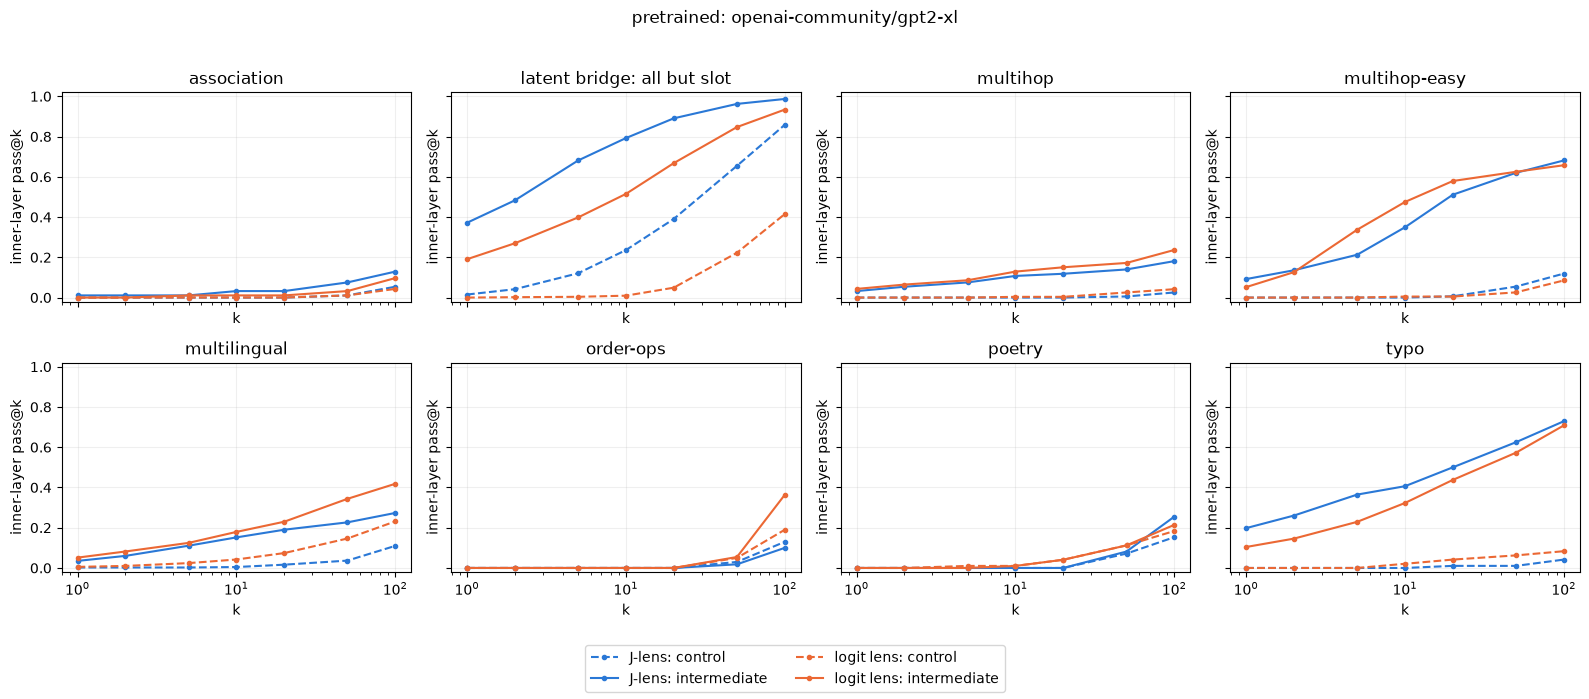

In [12]:
curve_tables = []
for scope in ["inner", "all blocks"]:
    bridge = latent_scores[
        latent_scores.subset.eq("all candidates") & latent_scores.dataset.eq("latent-bridge/all")
        & latent_scores.span.eq("all but slot") & latent_scores.scope.eq(scope)
    ].copy()
    bridge["dataset"] = "latent bridge: all but slot"
    curve_tables += [bridge, anthropic_scores[anthropic_scores.scope.eq(scope)]]
curves = pd.concat(curve_tables, ignore_index=True)
curves = curves[curves.kind.isin(["intermediate", "control"])]
auc_rows = []
for keys, group in curves.groupby(["dataset", "scope", "lens", "kind"]):
    group = group.sort_values("k")
    auc_rows.append(dict(zip(["dataset", "scope", "lens", "kind"], keys, strict=True),
                         auc=np.trapezoid(group.score, np.log(group.k)) / np.log(100)))
auc = pd.DataFrame(auc_rows)
display(auc[auc.kind.eq("intermediate")].pivot(
    index=["dataset", "scope"], columns="lens", values="auc",
).round(3))

plot_groups = list(curves[curves.scope.eq("inner")].groupby("dataset"))
n_plot_rows = (len(plot_groups) + 3) // 4
fig, axes = plt.subplots(n_plot_rows, 4, figsize=(16, 3.5 * n_plot_rows),
                         sharex=True, sharey=True, squeeze=False)
for ax, (dataset, group) in zip(axes.flat, plot_groups, strict=False):
    for (lens_name, kind), line in group.groupby(["lens", "kind"]):
        ax.plot(line.k, line.score, color=COLORS[lens_name],
                linestyle="-" if kind == "intermediate" else "--", marker="o", ms=3,
                label=f"{lens_name}: {kind}")
    ax.set(xscale="log", ylim=(-0.02, 1.02), title=dataset, xlabel="k", ylabel="inner-layer pass@k")
    ax.grid(alpha=0.2)
for ax in list(axes.flat)[len(plot_groups):]:
    ax.axis("off")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2)
fig.suptitle(f"{RUN_MODE}: {run_model_id}")
fig.tight_layout(rect=(0, 0.09, 1, 0.96))
fig.savefig(RUN_DIR / "inner_pass_at_k.png", dpi=140)
plt.show()

## Where and when: layer profiles and an example position map

Depth uses block index / (number of blocks − 1); the final shared model output is 100%. Profiles weight items equally after averaging their supported intermediates. The heatmap uses one actual tokenization, avoiding an assumption that different subjects or tokenizers share the same template-token columns.

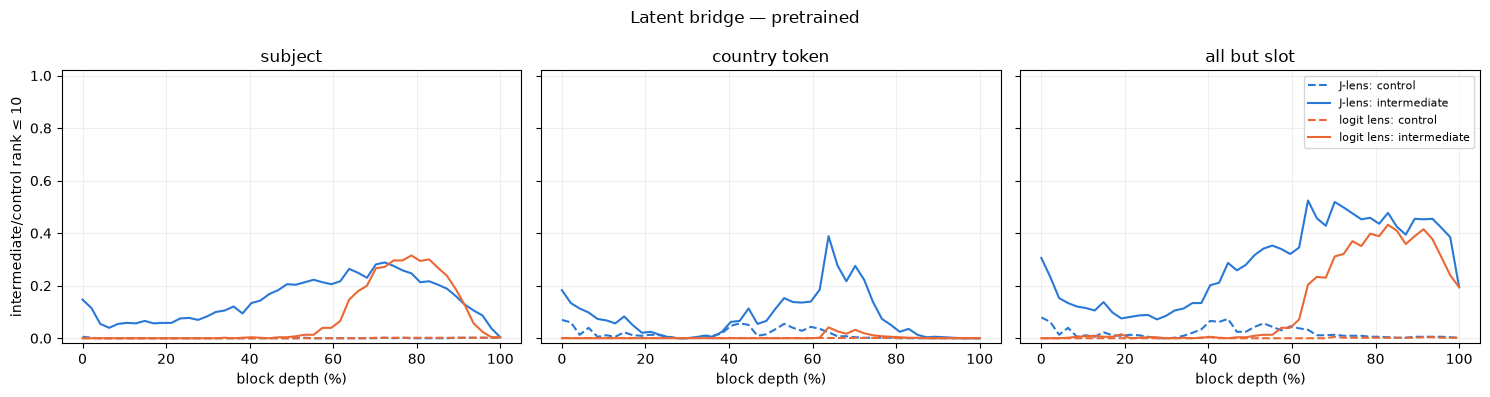

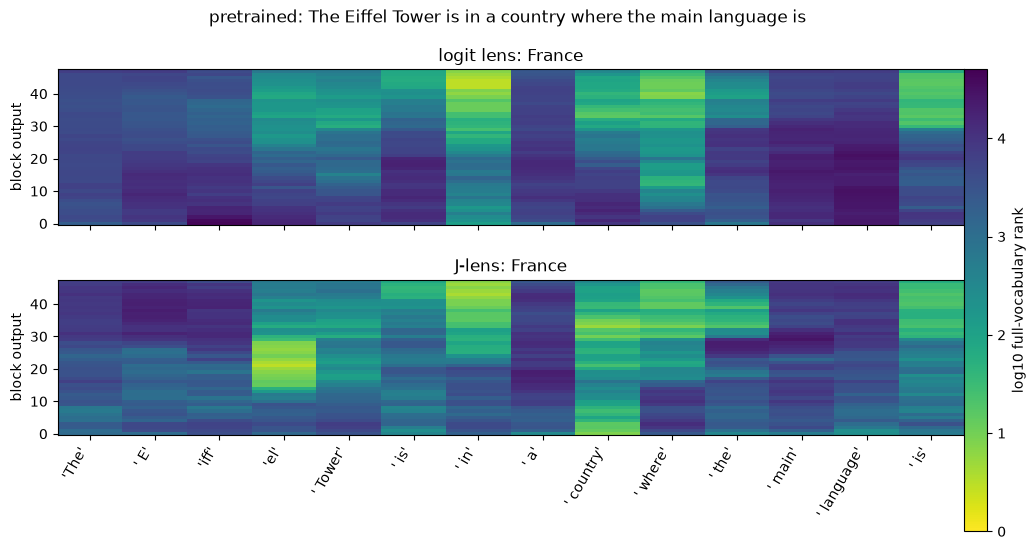

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
depth = np.linspace(0, 100, N_LAYERS)
for ax, span in zip(axes, ["subject", "country token", "all but slot"], strict=True):
    frame = span_words[span_words.span.eq(span) & span_words.kind.isin(["intermediate", "control"])]
    for (name, kind), group in frame.groupby(["lens", "kind"]):
        valid = group[group.ranks.notna()]
        if valid.empty:
            continue
        values = pd.DataFrame((np.stack(valid.ranks) <= K).astype(float))
        values["item"] = (valid.dataset + ":" + valid.item).to_numpy()
        curve = values.groupby("item").mean().mean()
        ax.plot(depth, curve, color=COLORS[name], linestyle="-" if kind == "intermediate" else "--",
                label=f"{name}: {kind}")
    ax.set(title=span, xlabel="block depth (%)", ylim=(-0.02, 1.02))
    ax.grid(alpha=0.2)
axes[0].set_ylabel(f"intermediate/control rank ≤ {K}")
axes[-1].legend(fontsize=8)
fig.suptitle(f"Latent bridge — {RUN_MODE}")
fig.tight_layout()
fig.savefig(RUN_DIR / "layer_profiles.png", dpi=140)
plt.show()

example = position_words[position_words.kind.eq("intermediate") & position_words.ranks.notna()].head(1)
if not example.empty:
    selected = example.iloc[0]
    item = latent_items[latent_items.dataset.eq(selected.dataset) & latent_items.item.eq(selected["item"])].iloc[0]
    rows = position_words[position_words.dataset.eq(selected.dataset) & position_words.item.eq(selected["item"])
                          & position_words.kind.eq("intermediate")]
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    for ax, row in zip(axes, rows.itertuples(), strict=True):
        image = ax.imshow(np.log10(row.ranks), aspect="auto", origin="lower", vmin=0,
                          vmax=max(1, np.log10(config.vocab_size)), cmap="viridis_r")
        ax.set(title=f"{row.lens}: {row.word}", ylabel="block output")
    labels = [repr(tokenizer.decode([item.ids[p]])) for p in selected.positions]
    axes[-1].set_xticks(range(len(labels)), labels, rotation=60, ha="right")
    fig.colorbar(image, ax=axes, label="log10 full-vocabulary rank", fraction=0.025)
    fig.suptitle(f"{RUN_MODE}: {item.prompt}")
    fig.subplots_adjust(bottom=0.27, hspace=0.35, right=0.88)
    fig.savefig(RUN_DIR / "position_example.png", dpi=140, bbox_inches="tight")
    plt.show()

## Paired comparisons and examples

A positive log10 rank gain means the J-lens finds the intermediate at a better best inner-layer rank. Latent-bridge pairs use all-but-slot positions; Anthropic pairs use the prescribed single position. The table counts word occurrences, while pass@k above weights items equally.

Multihop-easy also uses the final-token readout here. Its paraphrases are counted separately in this diagnostic; use the grouped scores above for the dataset-level comparison.

In [14]:
comparison_words = pd.concat([
    span_words[span_words.span.eq("all but slot")], anth_words,
], ignore_index=True)
comparison_words = comparison_words[
    comparison_words.kind.eq("intermediate") & comparison_words.ranks.notna()
].copy()
comparison_words["inner_best"] = comparison_words.ranks.map(lambda r: r[:-1].min())
paired = comparison_words.pivot(
    index=["dataset", "item", "word", "role"], columns="lens", values="inner_best",
)
paired["log10 gain"] = np.log10(paired["logit lens"]) - np.log10(paired["J-lens"])
paired["winner"] = np.select(
    [paired["J-lens"] < paired["logit lens"], paired["J-lens"] > paired["logit lens"]],
    ["J-lens", "logit lens"], default="tie",
)
paired_summary = paired.groupby("dataset").winner.value_counts().unstack(fill_value=0)
display(paired_summary.reindex(columns=["J-lens", "logit lens", "tie"], fill_value=0))
display(paired.sort_values("log10 gain", ascending=False).head(8))
display(paired.sort_values("log10 gain").head(8))

winner,J-lens,logit lens,tie
dataset,,,
association,60,33,0
latent-bridge/brand,61,10,12
latent-bridge/city,50,4,65
latent-bridge/food,85,16,2
latent-bridge/landmark,81,15,12
latent-bridge/person,94,11,12
multihop,39,60,4
multihop-easy,77,106,17
multilingual,143,231,24


lens                                            J-lens  logit lens  log10 gain  winner
dataset             item         word     role                                        
typo                typo-which   which    0         13        1611    2.093152  J-lens
                    typo-another another  0          1         109    2.037426  J-lens
latent-bridge/brand Armani       Italy    0          1          69    1.838849  J-lens
                    Lamborghini  Italy    0          1          64    1.806180  J-lens
latent-bridge/food  som tam      Thailand 0          2         116    1.763428  J-lens
                    tom yum      Thailand 0          3         172    1.758407  J-lens
latent-bridge/brand Chang        Thailand 0          3         145    1.684247  J-lens
                    Bimbo        Mexico   0          5         229    1.660865  J-lens

lens                                               J-lens  logit lens  log10 gain      winner
dataset      item                      word  role                                            
multilingual fr-half-six               six   2        220           1   -2.342423  logit lens
             frn-number-after-one      two   3        165           3   -1.740363  logit lens
             de-size-big-small         small 3        538          13   -1.616839  logit lens
multihop     letterpos-water-symbol    H     0        297          10   -1.472756  logit lens
multilingual irish-opposite-big        small 3        474          17   -1.445329  logit lens
multihop     letterpos-nitrogen-symbol N     0        236           9   -1.418669  logit lens
poetry       couplet-fight-light       light 0        697          29   -1.380835  logit lens
multilingual pt-time-after-night       time  1        972          44   -1.344214  logit lens

## Conclusions

The generated statements below describe the active run. A visibility advantage is evidence about a readout, not causal evidence that the model used that intermediate. Position sweeps offer more opportunities for a hit than a single-position protocol, so raw scores across the two suites are not directly comparable. Historical GPT-2 selection, current-model correctness, tokenizer coverage and fitting corpus can all change the comparison.

In [15]:
lines = []
if RUN_MODE == "smoke":
    lines.append("**Offline smoke only:** random tiny Llama plus identity Jacobians. "
                 "All paired ranks match; these results validate execution, not trained-model quality.")
else:
    lines.append(f"**Model:** `{run_model_id}` at `{resolved_revision}`; dtype `{run_dtype}`; BOS `{BOS_POLICY}`.")
    lines.append("Fitting provenance is recorded in the run manifest; unknown fields remain unverified.")
for dataset, group in curves[curves.scope.eq("inner") & curves.kind.eq("intermediate")
                              & curves.k.eq(K)].groupby("dataset"):
    rates = group.set_index("lens").score
    j, l = rates.get("J-lens", np.nan), rates.get("logit lens", np.nan)
    if pd.isna(j) or pd.isna(l):
        lines.append(f"{dataset}: no supported intermediate observations; pass@{K} unavailable.")
    else:
        lines.append(f"{dataset}: inner-layer pass@{K}, J-lens {j:.1%}, logit lens {l:.1%}; "
                     f"difference {100 * (j - l):+.1f} percentage points.")
lines.append("Multihop-easy uses phrasing/base/family aggregation; its easy label does not establish model success.")
lines.append("Anthropic protocol scores including the shared final block are reported separately above. "
             "Consult coverage and target support before comparing models.")
display(Markdown("\n\n".join(lines)))
latent_scores.to_csv(RUN_DIR / "latent_scores.csv", index=False)
anthropic_scores.to_csv(RUN_DIR / "anthropic_scores.csv", index=False)
easy_scores.to_csv(RUN_DIR / "multihop_easy_scores.csv", index=False)
auc.to_csv(RUN_DIR / "auc.csv", index=False)
accuracy.to_csv(RUN_DIR / "answer_accuracy.csv")
print("Rank cache, provenance, tables and figures:", RUN_DIR.relative_to(REPO))

**Model:** `openai-community/gpt2-xl` at `15ea56dee5df4983c59b2538573817e1667135e2`; dtype `torch.float32`; BOS `prepend`.

Fitting provenance is recorded in the run manifest; unknown fields remain unverified.

association: inner-layer pass@10, J-lens 3.2%, logit lens 1.1%; difference +2.2 percentage points.

latent bridge: all but slot: inner-layer pass@10, J-lens 79.2%, logit lens 51.5%; difference +27.7 percentage points.

multihop: inner-layer pass@10, J-lens 10.8%, logit lens 12.9%; difference -2.2 percentage points.

multihop-easy: inner-layer pass@10, J-lens 34.9%, logit lens 47.5%; difference -12.6 percentage points.

multilingual: inner-layer pass@10, J-lens 15.2%, logit lens 17.9%; difference -2.7 percentage points.

order-ops: inner-layer pass@10, J-lens 0.0%, logit lens 0.0%; difference +0.0 percentage points.

poetry: inner-layer pass@10, J-lens 0.0%, logit lens 1.0%; difference -1.0 percentage points.

typo: inner-layer pass@10, J-lens 40.6%, logit lens 32.3%; difference +8.3 percentage points.

Multihop-easy uses phrasing/base/family aggregation; its easy label does not establish model success.

Anthropic protocol scores including the shared final block are reported separately above. Consult coverage and target support before comparing models.

Rank cache, provenance, tables and figures: runs/model-agnostic-lens-benchmark/fe081dc72c96ff8ca50c
